# Gated Architectures — LSTM & GRU

**Notebook 9** showed that vanilla RNNs fail to learn long-range dependencies because gradients vanish exponentially over T timesteps.

The solution: add **gates** — learnable switches that control what information to remember, forget, and output.

```
  Vanilla RNN: h_t = tanh(W_hh·h_{t-1} + W_xh·x_t + b)
               ↑ one operation, gradient can only flow through tanh

  LSTM:  c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
               ↑ cell state flows through pure addition → gradient highway

  GRU:   h_t = (1-z_t) ⊙ h_{t-1} + z_t ⊙ ĥ_t
               ↑ simpler but similar gradient-preserving property
```

---
**Topics covered**
1. LSTM — Long Short-Term Memory (cell state + 3 gates)
2. LSTM equations and NumPy implementation from scratch
3. GRU — Gated Recurrent Unit (2 gates, simpler than LSTM)
4. LSTM vs GRU vs RNN — comparison
5. Stacked (deep) RNNs
6. Bidirectional LSTMs
7. Sequence-to-sequence (Encoder-Decoder) architecture
8. Application: text generation with LSTM
9. Application: named entity recognition (NER)
10. Application: multivariate time series with LSTM
11. The road to Transformers — attention motivation

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import string

np.random.seed(42)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, TensorDataset
    TORCH = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch {torch.__version__} | device: {device}')
except ImportError:
    TORCH = False
    print('PyTorch not found — NumPy demos will still run.')

PyTorch 2.7.0 | device: cpu


## 1. LSTM — Long Short-Term Memory

**Hochreiter & Schmidhuber, 1997** — one of the most cited papers in deep learning.

### Two States: Hidden + Cell

LSTM maintains two vectors:
- **h_t** (hidden state) — short-term memory, like vanilla RNN hidden state
- **c_t** (cell state) — long-term memory, flows through time with minimal modification

### Three Gates

| Gate | Symbol | Controls | Activation |
|---|---|---|---|
| **Forget gate** | f_t | How much of c_{t-1} to keep | sigmoid ∈ [0,1] |
| **Input gate** | i_t | How much of new candidate to add | sigmoid ∈ [0,1] |
| **Output gate** | o_t | What part of cell state to output | sigmoid ∈ [0,1] |

### Equations

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)  \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)  \quad \text{(input gate)}$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)  \quad \text{(candidate cell state)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t  \quad \text{(update cell state)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)  \quad \text{(output gate)}$$
$$h_t = o_t \odot \tanh(c_t)  \quad \text{(new hidden state)}$$

### Why the cell state gradient flows

$$c_t = f_t \odot c_{t-1} + \text{(new info)}$$

The gradient of `c_t` with respect to `c_{t-1}` is simply `f_t` — no weight matrix multiplication, no tanh saturation.  
This is the **constant error carousel** — gradients can flow back through hundreds of timesteps.

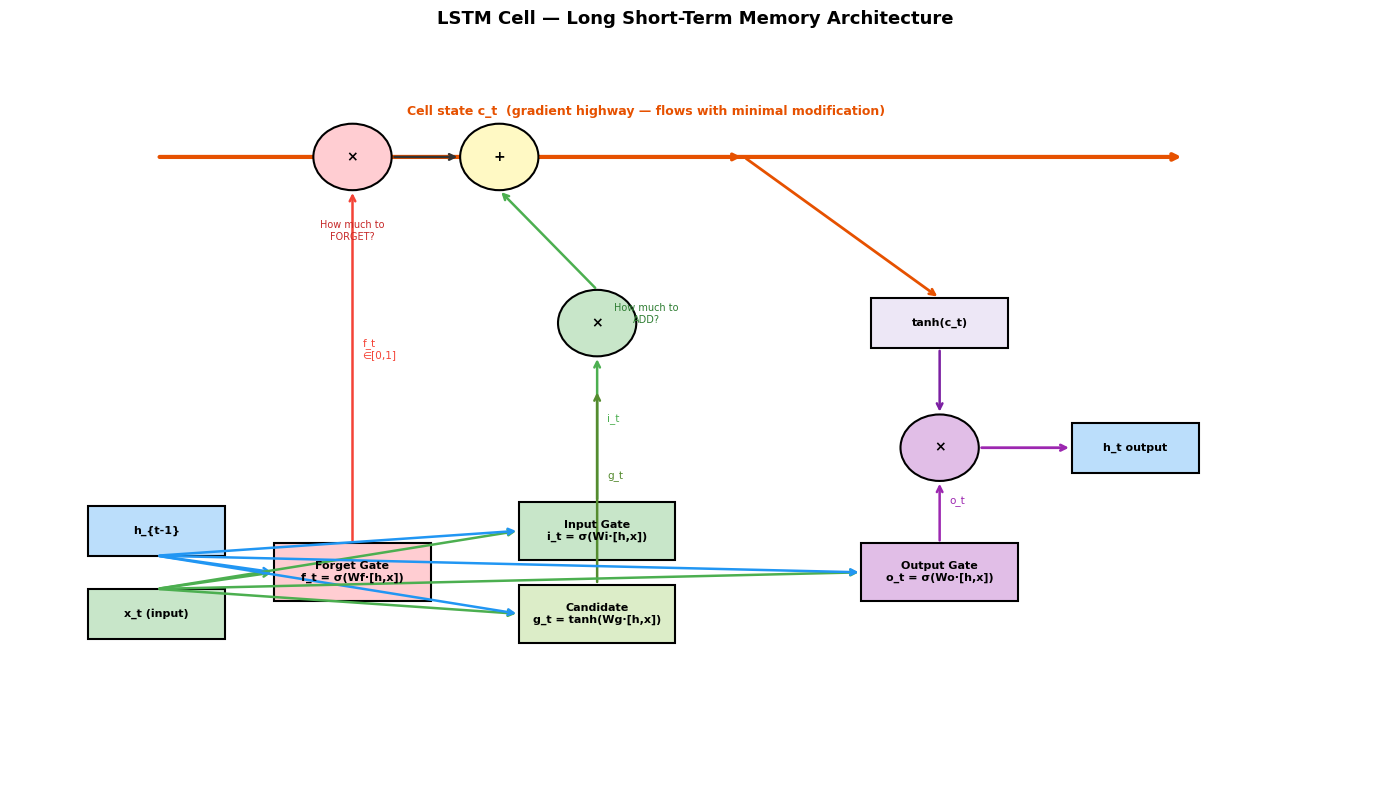

In [2]:
def draw_lstm_cell():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 14); ax.set_ylim(0, 9)
    ax.axis('off')

    def box(x, y, w, h, label, color, fontsize=8):
        rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                               facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', zorder=4)

    def circle(x, y, r, label, color):
        circ = plt.Circle((x, y), r, facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(circ)
        ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold', zorder=4)

    def arr(x1, y1, x2, y2, color='#333', lw=1.8, label=''):
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw))
        if label:
            ax.text((x1+x2)/2+0.1, (y1+y2)/2+0.1, label, fontsize=7.5, color=color)

    # ── Cell state line (top — the gradient highway) ──────────────────────────
    ax.annotate('', xy=(12, 7.5), xytext=(1.5, 7.5),
                arrowprops=dict(arrowstyle='->', color='#E65100', lw=3))
    ax.text(6.5, 8.0, 'Cell state c_t  (gradient highway — flows with minimal modification)',
            ha='center', fontsize=9, color='#E65100', fontweight='bold')

    # ── Inputs: x_t and h_{t-1} ───────────────────────────────────────────────
    box(1.5, 2.0, 1.4, 0.6, 'x_t (input)', '#C8E6C9')
    box(1.5, 3.0, 1.4, 0.6, 'h_{t-1}', '#BBDEFB')

    # ── Forget gate ───────────────────────────────────────────────────────────
    box(3.5, 2.5, 1.6, 0.7, 'Forget Gate\nf_t = σ(Wf·[h,x])', '#FFCDD2')
    circle(3.5, 7.5, 0.4, '×', '#FFCDD2')
    arr(1.5, 2.3, 3.5-0.8, 2.5, '#4CAF50')
    arr(1.5, 2.7, 3.5-0.8, 2.5, '#2196F3')
    arr(3.5, 2.85, 3.5, 7.1, '#F44336', label='f_t\n∈[0,1]')
    ax.text(3.5, 6.5, 'How much to\nFORGET?', ha='center', fontsize=7, color='#C62828')

    # ── Input gate ────────────────────────────────────────────────────────────
    box(6.0, 3.0, 1.6, 0.7, 'Input Gate\ni_t = σ(Wi·[h,x])', '#C8E6C9')
    box(6.0, 2.0, 1.6, 0.7, 'Candidate\ng_t = tanh(Wg·[h,x])', '#DCEDC8')
    circle(6.0, 5.5, 0.4, '×', '#C8E6C9')
    circle(5.0, 7.5, 0.4, '+', '#FFF9C4')
    arr(1.5, 2.3, 6.0-0.8, 3.0, '#4CAF50')
    arr(1.5, 2.7, 6.0-0.8, 3.0, '#2196F3')
    arr(1.5, 2.3, 6.0-0.8, 2.0, '#4CAF50')
    arr(1.5, 2.7, 6.0-0.8, 2.0, '#2196F3')
    arr(6.0, 3.35, 6.0, 5.1, '#4CAF50', label='i_t')
    arr(6.0, 2.35, 6.0, 4.7, '#558B2F', label='g_t')
    arr(6.0, 5.9, 5.0, 7.1, '#4CAF50')
    arr(3.9, 7.5, 4.6, 7.5, '#333')
    ax.text(6.5, 5.5, 'How much to\nADD?', ha='center', fontsize=7, color='#2E7D32')

    # ── After addition → new cell state ──────────────────────────────────────
    arr(5.4, 7.5, 7.5, 7.5, '#E65100', lw=2.5)

    # ── Output gate ───────────────────────────────────────────────────────────
    box(9.5, 2.5, 1.6, 0.7, 'Output Gate\no_t = σ(Wo·[h,x])', '#E1BEE7')
    box(9.5, 5.5, 1.4, 0.6, 'tanh(c_t)', '#EDE7F6')
    circle(9.5, 4.0, 0.4, '×', '#E1BEE7')
    arr(1.5, 2.3, 9.5-0.8, 2.5, '#4CAF50')
    arr(1.5, 2.7, 9.5-0.8, 2.5, '#2196F3')
    arr(9.5, 2.85, 9.5, 3.6, '#9C27B0', label='o_t')
    arr(9.5, 5.2, 9.5, 4.4, '#7B1FA2')
    arr(7.5, 7.5, 9.5, 5.8, '#E65100', lw=2)

    # ── Output h_t ────────────────────────────────────────────────────────────
    box(11.5, 4.0, 1.3, 0.6, 'h_t output', '#BBDEFB')
    arr(9.5+0.4, 4.0, 10.85, 4.0, '#9C27B0', lw=2)

    ax.set_title('LSTM Cell — Long Short-Term Memory Architecture', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_lstm_cell()

## 2. LSTM NumPy Implementation

LSTM forward pass:
  Input:        (10, 5)
  Hidden states: (10, 16)
  Final h:       (16,)
  Final c:       (16,)


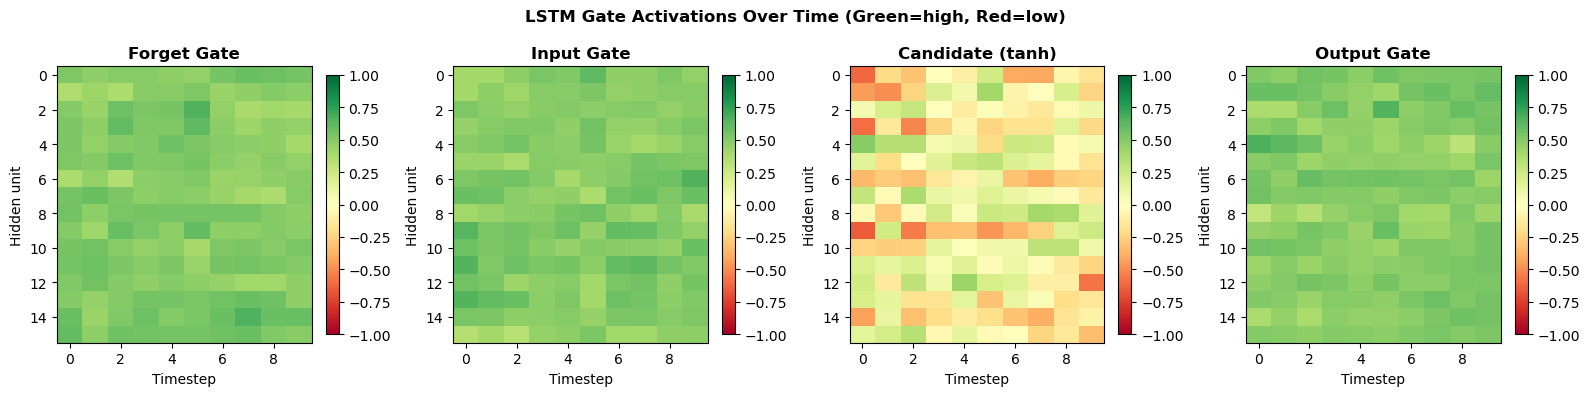


Gate statistics (mean across units):
  f (forget)                mean=0.504  std=0.058
  i (input)                 mean=0.500  std=0.060
  g (candidate)             mean=-0.037  std=0.243
  o (output)                mean=0.496  std=0.058


In [3]:
def sigmoid(x): return 1 / (1 + np.exp(-x))


class LSTMCell:
    """
    Single LSTM cell — processes one timestep.
    """
    def __init__(self, input_size, hidden_size):
        D, H = input_size, hidden_size
        scale = 0.1
        # All 4 gates packed into one matrix for efficiency: [f, i, g, o]
        self.W_ih = np.random.randn(4*H, D) * scale   # input → gates
        self.W_hh = np.random.randn(4*H, H) * scale   # hidden → gates
        self.b    = np.zeros(4*H)
        self.H    = H

    def forward(self, x, h_prev, c_prev):
        """
        x:      (D,)  — input at this timestep
        h_prev: (H,)  — previous hidden state
        c_prev: (H,)  — previous cell state

        Returns: (h_t, c_t) — new hidden and cell states
        """
        H = self.H
        # Combined pre-activation for all 4 gates
        gates = self.W_ih @ x + self.W_hh @ h_prev + self.b

        f = sigmoid(gates[0*H : 1*H])   # forget gate
        i = sigmoid(gates[1*H : 2*H])   # input gate
        g = np.tanh( gates[2*H : 3*H])  # candidate (gate)
        o = sigmoid(gates[3*H : 4*H])   # output gate

        c_t = f * c_prev + i * g        # new cell state
        h_t = o * np.tanh(c_t)          # new hidden state

        return h_t, c_t, {'f': f, 'i': i, 'g': g, 'o': o}

    def forward_sequence(self, X):
        """
        X: (T, D) sequence
        Returns: (T, H) hidden states, final (h, c)
        """
        T, D = X.shape
        H    = self.H
        h    = np.zeros(H)
        c    = np.zeros(H)
        hs   = np.zeros((T, H))
        all_gates = []

        for t in range(T):
            h, c, gates = self.forward(X[t], h, c)
            hs[t] = h
            all_gates.append(gates)

        return hs, (h, c), all_gates


# Demo
np.random.seed(42)
lstm = LSTMCell(input_size=5, hidden_size=16)

# Process a sequence of 10 timesteps
T, D = 10, 5
X = np.random.randn(T, D)
hs, (h_final, c_final), gate_vals = lstm.forward_sequence(X)

print('LSTM forward pass:')
print(f'  Input:        ({T}, {D})')
print(f'  Hidden states: ({T}, {lstm.H})')
print(f'  Final h:       {h_final.shape}')
print(f'  Final c:       {c_final.shape}')

# Visualise gate activations
gate_names = ['f (forget)', 'i (input)', 'g (candidate)', 'o (output)']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, gname in zip(axes, ['f','i','g','o']):
    gate_matrix = np.stack([v[gname] for v in gate_vals])  # (T, H)
    im = ax.imshow(gate_matrix.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Hidden unit')
    long_name = {'f':'Forget Gate','i':'Input Gate','g':'Candidate (tanh)','o':'Output Gate'}[gname]
    ax.set_title(f'{long_name}', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('LSTM Gate Activations Over Time (Green=high, Red=low)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nGate statistics (mean across units):')
for gname, full in zip(['f','i','g','o'], gate_names):
    vals = np.stack([v[gname] for v in gate_vals])
    print(f'  {full:<25} mean={vals.mean():.3f}  std={vals.std():.3f}')

## 3. GRU — Gated Recurrent Unit

**Cho et al., 2014** — Simplified LSTM: 2 gates, no separate cell state.

### Equations

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])  \quad \text{(update gate — like LSTM's forget + input combined)}$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])  \quad \text{(reset gate — how much past to consider)}$$
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])  \quad \text{(candidate hidden state)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t  \quad \text{(new hidden state)}$$

### Key Intuition
- **Update gate z_t**: How much to update h_{t-1} with new information  
  - z_t = 0 → keep h_{t-1} exactly (remember everything)
  - z_t = 1 → fully replace with ĥ_t
- **Reset gate r_t**: How much of h_{t-1} to use when computing the candidate

Parameter comparison (D=32, H=128):
  Vanilla RNN:   20,736
  GRU:           61,824  (3.0× more than RNN)
  LSTM:          82,432  (4.0× more than RNN)
  GRU/LSTM ratio: 0.75


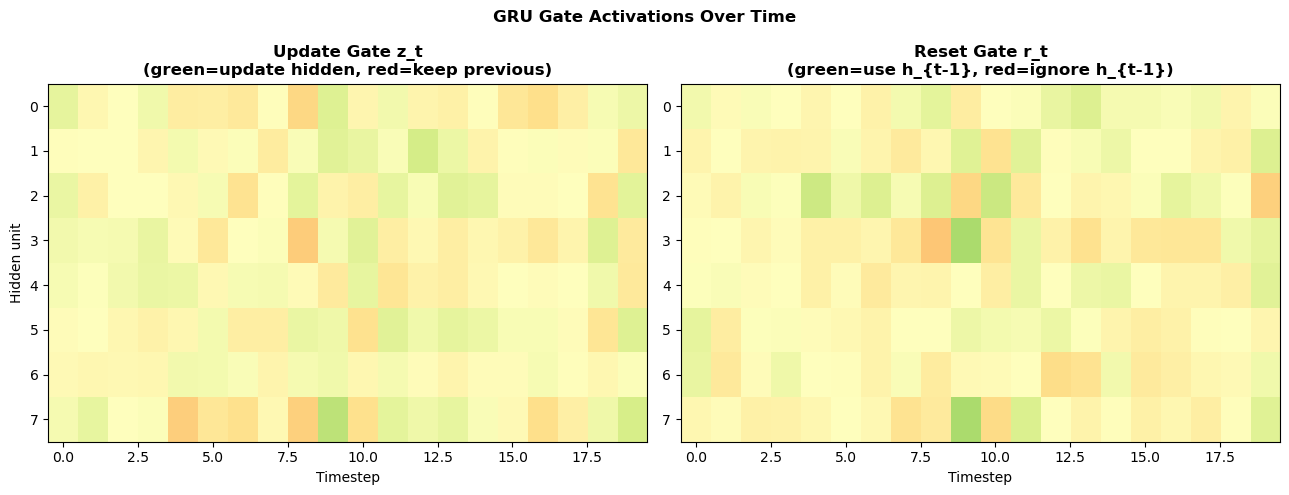

In [4]:
class GRUCell:
    """Single GRU cell."""
    def __init__(self, input_size, hidden_size):
        D, H = input_size, hidden_size
        scale = 0.1
        self.W_z = np.random.randn(H, D+H) * scale  # update gate
        self.b_z = np.zeros(H)
        self.W_r = np.random.randn(H, D+H) * scale  # reset gate
        self.b_r = np.zeros(H)
        self.W_h = np.random.randn(H, D+H) * scale  # candidate
        self.b_h = np.zeros(H)
        self.H   = H

    def forward(self, x, h_prev):
        combined = np.concatenate([x, h_prev])

        z   = sigmoid(self.W_z @ combined + self.b_z)   # update gate
        r   = sigmoid(self.W_r @ combined + self.b_r)   # reset gate

        # Candidate: reset gate controls how much of h_prev to use
        combined_r = np.concatenate([x, r * h_prev])
        h_tilde    = np.tanh(self.W_h @ combined_r + self.b_h)

        # Interpolate between old and candidate
        h_t = (1 - z) * h_prev + z * h_tilde
        return h_t, {'z': z, 'r': r, 'h_tilde': h_tilde}


# Compare LSTM vs GRU parameter counts
D, H = 32, 128

lstm_params = 4 * (H*H + H*D + H)  # 4 gates
gru_params  = 3 * (H*(D+H) + H)    # 3 matrices (z, r, h)
rnn_params  = H*H + H*D + H + H    # 1 gate

print(f'Parameter comparison (D={D}, H={H}):')
print(f'  Vanilla RNN: {rnn_params:>8,}')
print(f'  GRU:         {gru_params:>8,}  ({gru_params/rnn_params:.1f}× more than RNN)')
print(f'  LSTM:        {lstm_params:>8,}  ({lstm_params/rnn_params:.1f}× more than RNN)')
print(f'  GRU/LSTM ratio: {gru_params/lstm_params:.2f}')

# Visualise the GRU update mechanism
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gate behavior simulation
T = 20
gru = GRUCell(5, 8)
h = np.zeros(8)
Z_vals, R_vals = [], []
for t in range(T):
    x = np.random.randn(5)
    h, info = gru.forward(x, h)
    Z_vals.append(info['z'])
    R_vals.append(info['r'])

Z_mat = np.stack(Z_vals)  # (T, H)
R_mat = np.stack(R_vals)

axes[0].imshow(Z_mat.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Update Gate z_t\n(green=update hidden, red=keep previous)',
                   fontweight='bold')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Hidden unit')

axes[1].imshow(R_mat.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title('Reset Gate r_t\n(green=use h_{t-1}, red=ignore h_{t-1})',
                   fontweight='bold')
axes[1].set_xlabel('Timestep')

plt.suptitle('GRU Gate Activations Over Time', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. LSTM vs GRU vs RNN — Comparison

Architecture     Gates  States       Memory    Params (H=128,D=32)
----------------------------------------------------------------------
Vanilla RNN          0       1         Short                20,736
GRU                  2       1          Long                61,824
LSTM                 3       2     Very Long                82,432

When to choose:
  Vanilla RNN → Very short sequences (<10 steps), prototype, educational
  GRU         → Similar performance to LSTM, fewer parameters, faster training
  LSTM        → When long-range dependencies matter most
  Transformer → Very long sequences, parallelizable, state-of-the-art NLP

Copy task (T=30): remember token from position 0, predict at end
  RNN   final acc=12.8%
  GRU   final acc=28.2%
  LSTM  final acc=11.5%


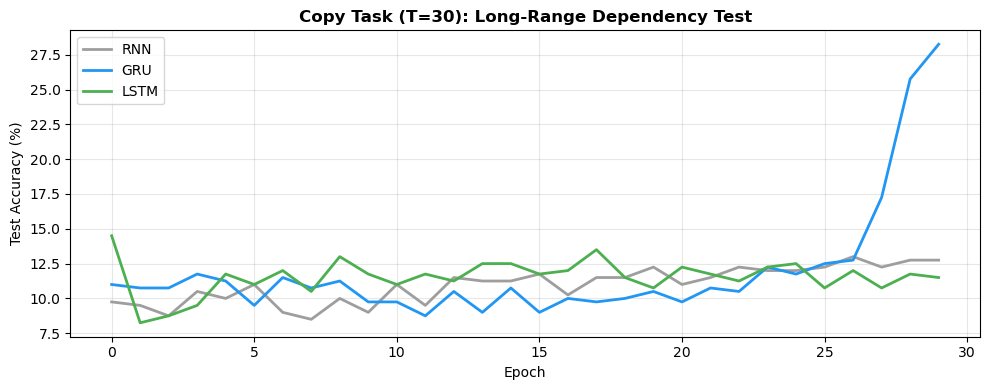

In [5]:
comparison_data = [
    ('Vanilla RNN', ['W_hh, W_xh, b'], 0, 'tanh', 1, 'Short', '#9E9E9E'),
    ('GRU',         ['W_z, W_r, W_h'], 2, 'tanh+sigmoid', 1, 'Long', '#2196F3'),
    ('LSTM',        ['W_f,W_i,W_g,W_o'],3,'tanh+sigmoid', 2, 'Very Long', '#4CAF50'),
]

print(f'{"Architecture":<15} {"Gates":>6} {"States":>7} {"Memory":>12} {"Params (H=128,D=32)":>22}')
print('-' * 70)
for name, matrices, gates, activ, states, memory, col in comparison_data:
    params = {'Vanilla RNN': rnn_params, 'GRU': gru_params, 'LSTM': lstm_params}[name]
    print(f'{name:<15} {gates:>6}  {states:>6}  {memory:>12}  {params:>20,}')

# When to choose which
print('\nWhen to choose:')
print('  Vanilla RNN → Very short sequences (<10 steps), prototype, educational')
print('  GRU         → Similar performance to LSTM, fewer parameters, faster training')
print('  LSTM        → When long-range dependencies matter most')
print('  Transformer → Very long sequences, parallelizable, state-of-the-art NLP')

# Performance comparison chart
if TORCH:
    # Quick benchmark: copy task (remember first token at position T)
    def copy_task_data(n=1000, T=20, vocab=10):
        """First element of sequence must be predicted at the last step."""
        xs = np.random.randint(1, vocab, (n, T))
        xs_t = torch.LongTensor(xs)
        ys_t = torch.LongTensor(xs[:, 0])   # predict first element
        return xs_t, ys_t

    VOCAB, SEQ = 10, 30
    X_copy, y_copy = copy_task_data(n=2000, T=SEQ, vocab=VOCAB)
    n_tr = 1600
    tr_ds = TensorDataset(X_copy[:n_tr], y_copy[:n_tr])
    te_ds = TensorDataset(X_copy[n_tr:], y_copy[n_tr:])
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)

    class SeqClassifier(nn.Module):
        def __init__(self, cell_type, vocab, embed=16, hidden=32):
            super().__init__()
            self.emb = nn.Embedding(vocab, embed)
            if cell_type == 'rnn':
                self.rnn = nn.RNN(embed, hidden, batch_first=True)
            elif cell_type == 'gru':
                self.rnn = nn.GRU(embed, hidden, batch_first=True)
            else:
                self.rnn = nn.LSTM(embed, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, vocab)
            self.cell_type = cell_type

        def forward(self, x):
            e = self.emb(x)
            out = self.rnn(e)
            h   = out[1][0][-1] if self.cell_type == 'lstm' else out[1][-1]
            return self.fc(h)

    def train_copy(cell_type, epochs=30):
        model = SeqClassifier(cell_type, VOCAB).to(device)
        opt   = optim.Adam(model.parameters(), lr=1e-3)
        accs  = []
        for _ in range(epochs):
            model.train()
            for xb, yb in tr_ld:
                xb, yb = xb.to(device), yb.to(device)
                loss = F.cross_entropy(model(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for xb, yb in te_ld:
                    xb, yb = xb.to(device), yb.to(device)
                    correct += (model(xb).argmax(1) == yb).sum().item()
                    total   += len(yb)
            accs.append(correct/total*100)
        print(f'  {cell_type.upper():<5} final acc={accs[-1]:.1f}%')
        return accs

    print(f'\nCopy task (T={SEQ}): remember token from position 0, predict at end')
    results = {}
    for ct in ['rnn', 'gru', 'lstm']:
        results[ct] = train_copy(ct)

    fig, ax = plt.subplots(figsize=(10, 4))
    cols = {'rnn':'#9E9E9E','gru':'#2196F3','lstm':'#4CAF50'}
    for ct, accs in results.items():
        ax.plot(accs, lw=2, color=cols[ct], label=ct.upper())
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'Copy Task (T={SEQ}): Long-Range Dependency Test', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Stacked (Deep) RNNs and Bidirectional LSTMs

### Stacked RNNs
Stack multiple RNN/LSTM layers — the output of layer `k` becomes the input sequence of layer `k+1`:

```
  Layer 2: ──► LSTM ──► LSTM ──► LSTM ──►  h₂_T
                ↑          ↑          ↑
  Layer 1: ──► LSTM ──► LSTM ──► LSTM ──►  h₁_T
                ↑          ↑          ↑
  Input:        x₁         x₂         x₃
```

### Bidirectional LSTM (BiLSTM)
Process the sequence in both directions and concatenate hidden states:

```
  Forward:   x₁ →  x₂ →  x₃ → x₄     h_f_T
  Backward:  x₁ ←  x₂ ←  x₃ ← x₄     h_b_1

  At each t: h_t = [h_f_t ; h_b_t]    (concatenated)
```

BiLSTM is used for tasks where **context from the future** is available (classification, NER, POS tagging)  
but **not** for tasks where future is unknown (language modeling, time series forecasting).

In [6]:
if TORCH:
    # Demonstrate stacked and bidirectional LSTM configurations
    batch, T, D = 4, 20, 16
    H = 32
    x = torch.randn(batch, T, D)

    configs = [
        ('Vanilla LSTM (1 layer)', dict(input_size=D, hidden_size=H, num_layers=1, batch_first=True, bidirectional=False)),
        ('Stacked LSTM (2 layers)', dict(input_size=D, hidden_size=H, num_layers=2, batch_first=True, bidirectional=False, dropout=0.2)),
        ('Stacked LSTM (4 layers)', dict(input_size=D, hidden_size=H, num_layers=4, batch_first=True, bidirectional=False, dropout=0.2)),
        ('BiLSTM (1 layer)', dict(input_size=D, hidden_size=H, num_layers=1, batch_first=True, bidirectional=True)),
        ('Stacked BiLSTM (2 layers)', dict(input_size=D, hidden_size=H, num_layers=2, batch_first=True, bidirectional=True, dropout=0.2)),
    ]

    print(f'Input shape: {tuple(x.shape)}  (batch={batch}, T={T}, D={D})')
    print(f'\n{"Configuration":<30} {"Output shape":>18} {"h_n shape":>18} {"Params":>10}')
    print('-' * 82)
    for name, kw in configs:
        lstm = nn.LSTM(**kw)
        with torch.no_grad():
            out, (h_n, c_n) = lstm(x)
        n_params = sum(p.numel() for p in lstm.parameters())
        print(f'{name:<30} {str(tuple(out.shape)):>18} {str(tuple(h_n.shape)):>18} {n_params:>10,}')

Input shape: (4, 20, 16)  (batch=4, T=20, D=16)

Configuration                        Output shape          h_n shape     Params
----------------------------------------------------------------------------------
Vanilla LSTM (1 layer)                (4, 20, 32)         (1, 4, 32)      6,400
Stacked LSTM (2 layers)               (4, 20, 32)         (2, 4, 32)     14,848
Stacked LSTM (4 layers)               (4, 20, 32)         (4, 4, 32)     31,744
BiLSTM (1 layer)                      (4, 20, 64)         (2, 4, 32)     12,800
Stacked BiLSTM (2 layers)             (4, 20, 64)         (4, 4, 32)     37,888


## 6. Application: Text Generation with LSTM

We train a word-level LSTM language model and generate new text by sampling from it.

Vocabulary: 72 words | Training sequences: 447
Training LSTM language model...
  Epoch 10 | loss=1.099
  Epoch 20 | loss=0.274
  Epoch 30 | loss=0.115
  Epoch 40 | loss=0.086
  Epoch 50 | loss=0.079


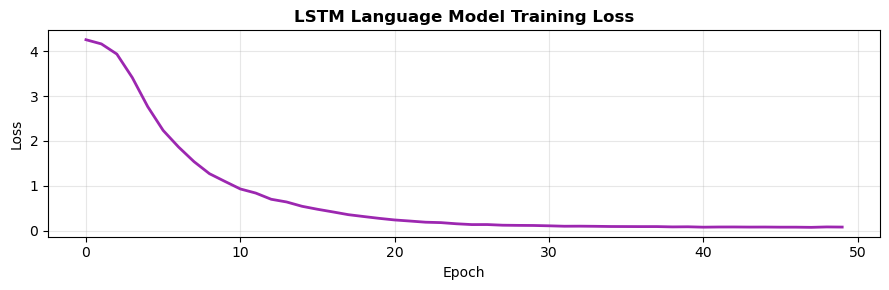

In [7]:
if TORCH:
    # Training corpus
    corpus = (
        "the quick brown fox jumps over the lazy dog "
        "a neural network learns to predict the next word "
        "deep learning models can generate text that sounds natural "
        "recurrent networks process sequences one step at a time "
        "the hidden state stores information about all previous inputs "
        "long short term memory networks solve the vanishing gradient problem "
        "gated recurrent units are simpler but equally powerful "
        "attention mechanisms allow models to focus on relevant parts "
        "transformers replaced recurrent networks for most language tasks "
        "the quick brown fox and the lazy dog are classic examples "
    ) * 5

    words   = corpus.split()
    vocab_w = sorted(set(words))
    w2i     = {w: i for i, w in enumerate(vocab_w)}
    i2w     = {i: w for w, i in w2i.items()}
    V       = len(vocab_w)
    SEQ_LEN = 8

    data_ids = [w2i[w] for w in words]
    Xs_lm = [data_ids[i:i+SEQ_LEN]   for i in range(len(data_ids)-SEQ_LEN)]
    ys_lm = [data_ids[i+SEQ_LEN]     for i in range(len(data_ids)-SEQ_LEN)]

    X_lm_t = torch.LongTensor(Xs_lm)
    y_lm_t = torch.LongTensor(ys_lm)
    lm_loader = DataLoader(TensorDataset(X_lm_t, y_lm_t), batch_size=32, shuffle=True)

    print(f'Vocabulary: {V} words | Training sequences: {len(Xs_lm)}')

    class LSTMLanguageModel(nn.Module):
        def __init__(self, vocab, embed=32, hidden=128, layers=2, dropout=0.3):
            super().__init__()
            self.embed = nn.Embedding(vocab, embed)
            self.lstm  = nn.LSTM(embed, hidden, num_layers=layers, batch_first=True,
                                  dropout=dropout)
            self.fc    = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, vocab))

        def forward(self, x):
            e        = self.embed(x)           # (B, T, embed)
            out, _   = self.lstm(e)            # (B, T, hidden)
            return self.fc(out[:, -1, :])      # predict next word from last step

    lm_model = LSTMLanguageModel(V).to(device)
    lm_opt   = optim.Adam(lm_model.parameters(), lr=1e-3, weight_decay=1e-4)
    lm_sch   = optim.lr_scheduler.CosineAnnealingLR(lm_opt, T_max=50)

    print('Training LSTM language model...')
    lm_losses = []
    for epoch in range(1, 51):
        lm_model.train()
        el = 0
        for xb, yb in lm_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.cross_entropy(lm_model(xb), yb)
            lm_opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(lm_model.parameters(), 1.0)
            lm_opt.step()
            el += loss.item()
        lm_sch.step()
        lm_losses.append(el / len(lm_loader))
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:>2} | loss={lm_losses[-1]:.3f}')

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(lm_losses, color='#9C27B0', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('LSTM Language Model Training Loss', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
if TORCH:
    def generate_text(model, seed_words, n_words=20, temperature=1.0):
        model.eval()
        tokens = [w2i.get(w, 0) for w in seed_words[-SEQ_LEN:]]
        generated = list(seed_words)

        for _ in range(n_words):
            seq = torch.LongTensor([tokens[-SEQ_LEN:]]).to(device)
            with torch.no_grad():
                logits = model(seq) / temperature
                probs  = F.softmax(logits, dim=-1).cpu().numpy().ravel()
                next_idx = np.random.choice(V, p=probs)
            generated.append(i2w[next_idx])
            tokens.append(next_idx)

        return ' '.join(generated)

    seeds = ['the', 'deep', 'neural']
    temps = [0.5, 1.0, 1.5]
    print('Generated text samples:')
    print('=' * 65)
    for seed in seeds:
        for temp in temps:
            gen = generate_text(lm_model, [seed], n_words=15, temperature=temp)
            print(f'  τ={temp} | seed="{seed}" | {gen}')
        print()

Generated text samples:
  τ=0.5 | seed="the" | the mechanisms gated simpler equally powerful powerful powerful powerful attention to focus focus most on relevant
  τ=1.0 | seed="the" | the previous are quick the the neural information are lazy to previous simpler predict word the
  τ=1.5 | seed="the" | the gated quick networks step text to dog one the the recurrent state models inputs fox

  τ=0.5 | seed="deep" | deep tasks term networks networks vanishing vanishing gradient gradient a gated recurrent units are are vanishing
  τ=1.0 | seed="deep" | deep time process generate can text text previous stores all networks networks the the the information
  τ=1.5 | seed="deep" | deep models network fox that relevant replaced natural parts the sequences language solve the hidden gated

  τ=0.5 | seed="neural" | neural classic time inputs for the term term the the are and information about about network
  τ=1.0 | seed="neural" | neural learns learning the but brown quick brown brown models mec

## 7. Application: Named Entity Recognition (NER)

NER is a **many-to-many** task: label each token in a sentence with its entity type.

```
  Input:  ["Barack", "Obama", "was", "born", "in", "Hawaii"]
  Output: [  B-PER,   I-PER,   O,     O,     O,    B-LOC  ]

  B- = Beginning of entity
  I- = Inside entity (continuation)
  O  = Outside (not an entity)
```

In [9]:
if TORCH:
    # Synthetic NER dataset
    PERSON_NAMES = ['Alice', 'Bob', 'Charlie', 'Diana', 'Edward']
    LOCATIONS    = ['London', 'Paris', 'Tokyo', 'Berlin', 'Sydney']
    ORGS         = ['Google', 'Apple', 'Microsoft', 'Amazon', 'Meta']
    NEUTRAL      = ['the', 'is', 'works', 'at', 'in', 'and', 'a', 'was', 'visited']

    tag2idx = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-LOC': 3, 'B-ORG': 4}
    idx2tag = {v: k for k, v in tag2idx.items()}

    def make_ner_sentence():
        templates = [
            ([np.random.choice(PERSON_NAMES), 'works', 'at', np.random.choice(ORGS)],
             ['B-PER', 'O', 'O', 'B-ORG']),
            ([np.random.choice(PERSON_NAMES), 'visited', np.random.choice(LOCATIONS)],
             ['B-PER', 'O', 'B-LOC']),
            ([np.random.choice(ORGS), 'is', 'in', np.random.choice(LOCATIONS)],
             ['B-ORG', 'O', 'O', 'B-LOC']),
            (['the', np.random.choice(PERSON_NAMES), 'and', np.random.choice(PERSON_NAMES), 'met'],
             ['O', 'B-PER', 'O', 'B-PER', 'O']),
        ]
        return templates[np.random.randint(len(templates))]

    # Build vocab
    all_words = PERSON_NAMES + LOCATIONS + ORGS + NEUTRAL + ['<pad>']
    word2idx_ner = {w: i+1 for i, w in enumerate(all_words)}; word2idx_ner['<pad>'] = 0
    NER_VOCAB    = len(word2idx_ner)
    MAX_LEN_NER  = 6

    def encode_ner(words, tags, max_len=MAX_LEN_NER):
        xids = [word2idx_ner.get(w, 0) for w in words]
        yids = [tag2idx[t] for t in tags]
        # Pad
        xids += [0] * (max_len - len(xids))
        yids += [0] * (max_len - len(yids))  # O = 0
        return xids[:max_len], yids[:max_len]

    N = 1000
    np.random.seed(42)
    X_ner, y_ner = [], []
    for _ in range(N):
        words, tags = make_ner_sentence()
        xids, yids  = encode_ner(words, tags)
        X_ner.append(xids); y_ner.append(yids)

    X_ner_t = torch.LongTensor(X_ner)
    y_ner_t = torch.LongTensor(y_ner)

    n_tr = 800
    ner_tr_ld = DataLoader(TensorDataset(X_ner_t[:n_tr], y_ner_t[:n_tr]), batch_size=32, shuffle=True)
    ner_te_ld = DataLoader(TensorDataset(X_ner_t[n_tr:], y_ner_t[n_tr:]), batch_size=64)

    class BiLSTM_NER(nn.Module):
        """
        Bidirectional LSTM for Named Entity Recognition.
        Output: tag distribution at EVERY position (many-to-many).
        """
        def __init__(self, vocab, n_tags, embed=32, hidden=64):
            super().__init__()
            self.embed = nn.Embedding(vocab, embed, padding_idx=0)
            self.bilstm = nn.LSTM(embed, hidden, num_layers=1, batch_first=True,
                                   bidirectional=True)
            self.dropout = nn.Dropout(0.3)
            self.fc     = nn.Linear(hidden*2, n_tags)

        def forward(self, x):
            e        = self.dropout(self.embed(x))  # (B, T, E)
            out, _   = self.bilstm(e)               # (B, T, 2H)
            return self.fc(self.dropout(out))        # (B, T, n_tags)

    ner_model = BiLSTM_NER(NER_VOCAB, len(tag2idx)).to(device)
    ner_opt   = optim.Adam(ner_model.parameters(), lr=1e-3)

    print('Training BiLSTM-NER model...')
    for epoch in range(1, 21):
        ner_model.train()
        for xb, yb in ner_tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            logits = ner_model(xb)  # (B, T, n_tags)
            loss = F.cross_entropy(logits.view(-1, len(tag2idx)), yb.view(-1),
                                    ignore_index=0)  # ignore padding
            ner_opt.zero_grad(); loss.backward(); ner_opt.step()

    # Evaluate
    ner_model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in ner_te_ld:
            xb, yb = xb.to(device), yb.to(device)
            preds = ner_model(xb).argmax(-1)   # (B, T)
            mask  = yb != 0
            correct += ((preds == yb) & mask).sum().item()
            total   += mask.sum().item()
    print(f'NER token accuracy (non-padding): {correct/total*100:.1f}%')

    # Predict on a few examples
    idx2word_ner = {v: k for k, v in word2idx_ner.items()}
    print('\nSample predictions:')
    for i in range(5):
        xids = X_ner_t[n_tr+i:n_tr+i+1].to(device)
        with torch.no_grad():
            pred_tags = ner_model(xids).argmax(-1)[0].cpu().numpy()
        true_tags = y_ner_t[n_tr+i].numpy()
        words_shown = [idx2word_ner[xi.item()] for xi in X_ner_t[n_tr+i] if xi != 0]
        pred_shown  = [idx2tag[t] for t in pred_tags[:len(words_shown)]]
        true_shown  = [idx2tag[t] for t in true_tags[:len(words_shown)]]
        correct_str = '✔' if pred_shown == true_shown else '✗'
        print(f'  {correct_str} words: {words_shown}')
        print(f'    pred: {pred_shown}')
        print(f'    true: {true_shown}')

Training BiLSTM-NER model...
NER token accuracy (non-padding): 100.0%

Sample predictions:
  ✗ words: ['the', 'Charlie', 'and', 'Bob']
    pred: ['B-PER', 'B-PER', 'B-PER', 'B-PER']
    true: ['O', 'B-PER', 'O', 'B-PER']
  ✗ words: ['Diana', 'works', 'at', 'Google']
    pred: ['B-PER', 'B-PER', 'B-ORG', 'B-ORG']
    true: ['B-PER', 'O', 'O', 'B-ORG']
  ✗ words: ['Meta', 'is', 'in', 'Tokyo']
    pred: ['B-ORG', 'B-ORG', 'B-LOC', 'B-LOC']
    true: ['B-ORG', 'O', 'O', 'B-LOC']
  ✗ words: ['Diana', 'works', 'at', 'Apple']
    pred: ['B-PER', 'B-PER', 'B-ORG', 'B-ORG']
    true: ['B-PER', 'O', 'O', 'B-ORG']
  ✗ words: ['Diana', 'visited', 'Sydney']
    pred: ['B-PER', 'B-PER', 'B-LOC']
    true: ['B-PER', 'O', 'B-LOC']


## 8. Application: Multivariate Time Series with LSTM

Real-world time series often have **multiple features** (e.g., temperature + humidity + wind).

```
  Input per timestep: [feature_1, feature_2, ..., feature_M]   (shape: M)
  LSTM input_size = M (instead of 1 for univariate)
  Task: predict next K values of one or all features
```

Multivariate forecasting: 3 features, predict 5 steps ahead
  Epoch 10 | val_mse=0.0256
  Epoch 20 | val_mse=0.0235
  Epoch 30 | val_mse=0.0231


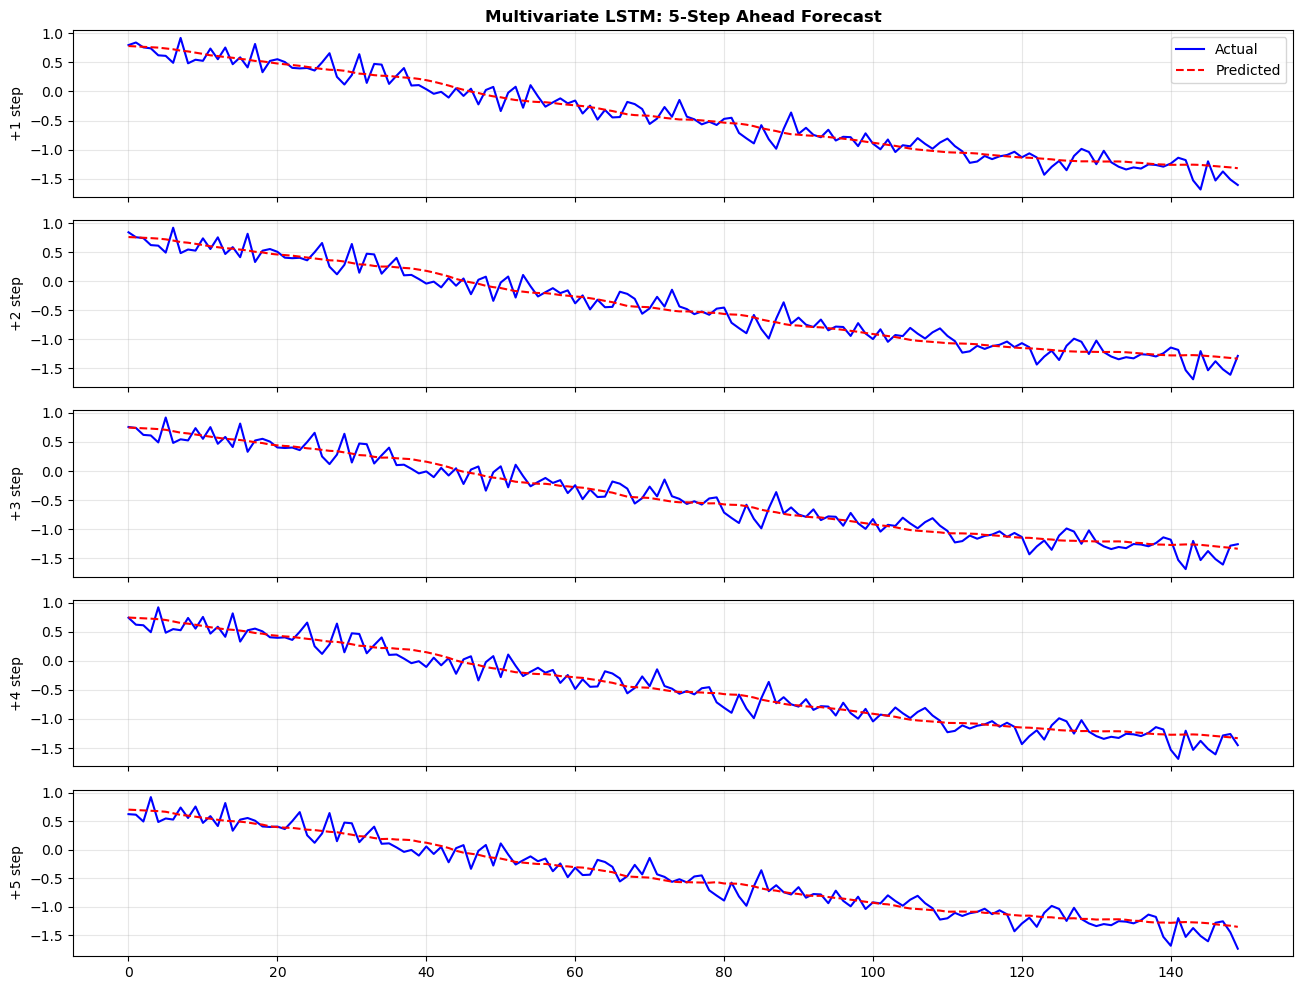

In [10]:
if TORCH:
    # Synthetic multivariate time series: 3 correlated features
    np.random.seed(42)
    T_total = 1500
    t = np.linspace(0, 6*np.pi, T_total)

    feat1 = np.sin(t) + 0.1 * np.random.randn(T_total)
    feat2 = np.cos(t) + 0.5*np.sin(2*t) + 0.1 * np.random.randn(T_total)
    feat3 = 0.5*np.sin(t + 0.5) + 0.3*np.random.randn(T_total)
    data  = np.stack([feat1, feat2, feat3], axis=1)   # (T, 3)

    # Normalize
    mean = data.mean(0); std = data.std(0)
    data = (data - mean) / std

    SEQ = 30; AHEAD = 5; N_FEAT = 3
    Xs_mv, ys_mv = [], []
    for i in range(len(data) - SEQ - AHEAD + 1):
        Xs_mv.append(data[i:i+SEQ])              # (SEQ, 3)
        ys_mv.append(data[i+SEQ:i+SEQ+AHEAD, 0]) # predict feat1 ahead steps

    X_mv = torch.FloatTensor(Xs_mv)
    y_mv = torch.FloatTensor(ys_mv)

    n_tr = int(0.8 * len(X_mv))
    mv_tr_ld = DataLoader(TensorDataset(X_mv[:n_tr], y_mv[:n_tr]), batch_size=64, shuffle=True)
    mv_te_ld = DataLoader(TensorDataset(X_mv[n_tr:], y_mv[n_tr:]), batch_size=128)

    class MultivariateLSTM(nn.Module):
        """LSTM for multivariate time series forecasting."""
        def __init__(self, n_features, hidden=64, n_layers=2, ahead=5, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(n_features, hidden, n_layers,
                                 batch_first=True, dropout=dropout)
            self.fc   = nn.Linear(hidden, ahead)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    mv_model = MultivariateLSTM(N_FEAT, hidden=64, ahead=AHEAD).to(device)
    mv_opt   = optim.Adam(mv_model.parameters(), lr=1e-3)
    mv_sch   = optim.lr_scheduler.ReduceLROnPlateau(mv_opt, patience=3)

    print(f'Multivariate forecasting: {N_FEAT} features, predict {AHEAD} steps ahead')
    mv_losses = []
    for epoch in range(1, 31):
        mv_model.train()
        tl = 0
        for xb, yb in mv_tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.mse_loss(mv_model(xb), yb)
            mv_opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(mv_model.parameters(), 1.0)
            mv_opt.step()
            tl += loss.item()

        mv_model.eval()
        vl = 0
        with torch.no_grad():
            for xb, yb in mv_te_ld:
                xb, yb = xb.to(device), yb.to(device)
                vl += F.mse_loss(mv_model(xb), yb).item()
        avg_vl = vl / len(mv_te_ld)
        mv_sch.step(avg_vl)
        mv_losses.append(avg_vl)
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:>2} | val_mse={avg_vl:.4f}')

    # Visualise
    mv_model.eval()
    with torch.no_grad():
        all_preds = []
        for xb, yb in mv_te_ld:
            all_preds.append(mv_model(xb.to(device)).cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_true  = y_mv[n_tr:].numpy()

    fig, axes = plt.subplots(AHEAD, 1, figsize=(13, 10), sharex=True)
    show = 150
    for step in range(AHEAD):
        axes[step].plot(all_true[:show, step],  'b-', lw=1.5, label='Actual')
        axes[step].plot(all_preds[:show, step], 'r--', lw=1.5, label='Predicted')
        axes[step].set_ylabel(f'+{step+1} step')
        if step == 0:
            axes[step].legend()
        axes[step].grid(alpha=0.3)
    axes[0].set_title(f'Multivariate LSTM: {AHEAD}-Step Ahead Forecast', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. The Road to Transformers — Attention Motivation

### The Bottleneck Problem

In sequence-to-sequence models (e.g., machine translation):

```
  Encoder:   "The cat sat on the mat" → [h₁, h₂, ..., h₆] → context vector c
                                                                       ↓ (bottleneck!)
  Decoder:   c → "Le chat s'est assis sur le tapis"
```

The **context vector** `c` (usually just `h_T` from the encoder) must compress the entire input sentence into a fixed-size vector.  
For long sentences, this bottleneck loses information.

### Attention: Let the Decoder Look Back

Instead of a single context vector, allow the decoder at each step to **attend** to all encoder hidden states:

$$\alpha_{t,i} = \text{softmax}(\text{score}(h^{dec}_t, h^{enc}_i))$$
$$c_t = \sum_i \alpha_{t,i} \cdot h^{enc}_i  \quad \text{(weighted sum of encoder states)}$$

The attention weights α tell the decoder: **"which input words to focus on when generating output word t"**.

This is the foundation of the **Transformer architecture** (Vaswani et al., 2017) — but that's a separate notebook.

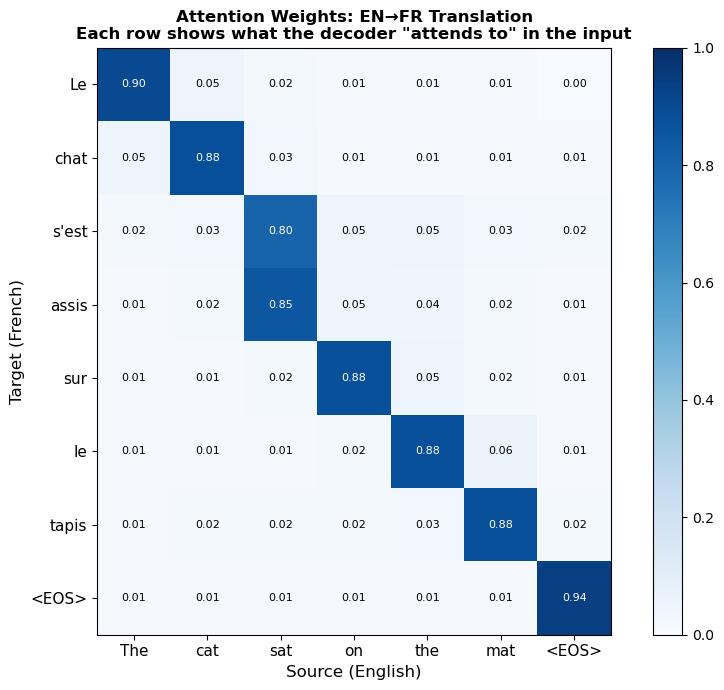

Key observations:
  • Mostly diagonal — French and English have similar word order
  • "s'est assis" (sat) both attend strongly to "sat" — multi-word expressions
  • The decoder learns alignment without being explicitly programmed

This attention mechanism is the core of Transformers (next major topic).


In [11]:
# Visualise attention weights as a heatmap
def draw_attention_heatmap():
    # Simulated attention weights for EN→FR translation
    src_words = ['The', 'cat', 'sat', 'on', 'the', 'mat', '<EOS>']
    tgt_words = ['Le', 'chat', 's\'est', 'assis', 'sur', 'le', 'tapis', '<EOS>']

    # Realistic attention pattern (mostly diagonal, some multi-token alignments)
    attn = np.array([
        [0.90, 0.05, 0.02, 0.01, 0.01, 0.01, 0.00],  # Le → The
        [0.05, 0.88, 0.03, 0.01, 0.01, 0.01, 0.01],  # chat → cat
        [0.02, 0.03, 0.80, 0.05, 0.05, 0.03, 0.02],  # s'est → sat
        [0.01, 0.02, 0.85, 0.05, 0.04, 0.02, 0.01],  # assis → sat
        [0.01, 0.01, 0.02, 0.88, 0.05, 0.02, 0.01],  # sur → on
        [0.01, 0.01, 0.01, 0.02, 0.88, 0.06, 0.01],  # le → the
        [0.01, 0.02, 0.02, 0.02, 0.03, 0.88, 0.02],  # tapis → mat
        [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.94],  # <EOS> → <EOS>
    ])

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_words))); ax.set_xticklabels(src_words, fontsize=11)
    ax.set_yticks(range(len(tgt_words))); ax.set_yticklabels(tgt_words, fontsize=11)
    ax.set_xlabel('Source (English)', fontsize=12)
    ax.set_ylabel('Target (French)', fontsize=12)
    for i in range(len(tgt_words)):
        for j in range(len(src_words)):
            ax.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if attn[i,j] < 0.7 else 'white')
    plt.colorbar(im, fraction=0.046)
    ax.set_title('Attention Weights: EN→FR Translation\n'
                  'Each row shows what the decoder "attends to" in the input',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_attention_heatmap()

print('Key observations:')
print('  • Mostly diagonal — French and English have similar word order')
print('  • "s\'est assis" (sat) both attend strongly to "sat" — multi-word expressions')
print('  • The decoder learns alignment without being explicitly programmed')
print('\nThis attention mechanism is the core of Transformers (next major topic).')

## 10. PyTorch Cheat Sheet — RNN/LSTM/GRU API

```python
# Instantiate
rnn  = nn.RNN( input_size, hidden_size, num_layers, batch_first=True, bidirectional=False)
lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=0.3)
gru  = nn.GRU( input_size, hidden_size, num_layers, batch_first=True, bidirectional=False)

# Forward pass
out, h_n        = rnn(x)          # x: (B, T, D)
out, (h_n, c_n) = lstm(x)         # LSTM returns tuple (h_n, c_n)
out, h_n        = gru(x)

# Output shapes (batch_first=True, bidirectional=True, L layers)
out.shape  # (B, T, H*2)       — output at every timestep
h_n.shape  # (L*2, B, H)       — final hidden state per layer per direction

# Common use cases:
# Sequence classification (many-to-one):
h_last = h_n[-1]                  # unidirectional
h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)  # bidirectional
logits = fc(h_last)

# Sequence labeling (many-to-many):
logits = fc(out)   # apply fc to every timestep output

# Gradient clipping (essential for RNNs):
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

## Summary

| Architecture | Gates | States | Strength | Weakness |
|---|---|---|---|---|
| **Vanilla RNN** | 0 | 1 (h) | Simple, fast | Vanishing gradient |
| **LSTM** | 3 (f, i, o) | 2 (h + c) | Long-range memory, stable | More parameters |
| **GRU** | 2 (z, r) | 1 (h) | Simpler than LSTM, fast | Slightly less expressive |
| **BiLSTM** | 3×2 | 2×2 | Full context (past + future) | 2× parameters, no generation |
| **Transformer** | Attention | None | Parallelizable, SOTA NLP | Quadratic in sequence length |

### Key Equations Summary

```
  Vanilla RNN:  h_t = tanh(W_hh·h_{t-1} + W_xh·x_t + b)

  LSTM:  f_t = σ(W_f·[h,x]),  i_t = σ(W_i·[h,x]),  o_t = σ(W_o·[h,x])
         c_t = f_t ⊙ c_{t-1} + i_t ⊙ tanh(W_g·[h,x])
         h_t = o_t ⊙ tanh(c_t)

  GRU:   z_t = σ(W_z·[h,x]),  r_t = σ(W_r·[h,x])
         h_t = (1-z_t)⊙h_{t-1} + z_t⊙tanh(W_h·[r_t⊙h_{t-1}, x_t])
```

### Gradient Comparison

| | Gradient through T steps |
|---|---|
| **Vanilla RNN** | Multiplied by W_hh × tanh' at each step → exponential decay |
| **LSTM** | Through cell state: `∂c_t/∂c_{t-1} = f_t` → just multiplication by f_t (≤1) |
| **GRU** | Through h_t: `∂h_t/∂h_{t-1} = 1-z_t` → controlled by update gate |

---
**Next notebook →** Attention & Transformers — self-attention, multi-head attention, positional encodings, and BERT/GPT architectures.